
# Lab_5: FEM 1D
Sofía Moscoso O

In [1]:
import numpy as np
import numpy.linalg as la
import pandas as pd
import time as tm
from scipy import interpolate
import scipy.integrate as integrate
import matplotlib.pyplot as plt

### Exercise 1: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(2-x)-x
\end{equation}

In [2]:
def FEM(N,Ua,Ub,funcion , x_0, x_f): #genralizacion para Dirichlet's conditions:  y(a),y(b),xϵ[a,b]
  h = 1/(N-1)
  u = np.zeros(N , float);
  b = np.zeros(N, float );

#steps: elements, malla
  xi = np.zeros(N ,float );
  for i in range(0,N):
    xi[i] = i*h

  # A matrix (integrated analytical)
  A = np.zeros((N, N), float );
  for i in range( 1 , N):
    A[i-1,i-1] = A[i-1,i-1] + 1/ h
    A[i-1,i] = A[i-1,i] - 1/h
    A[i,i-1] = A[i-1,i]
    A[i,i]= A[i,i] + 1/ h


  #phi(x) functions
  def lin1(x, x1, x2):
    return (x-x1)/(x2-x1)

  def lin2(x, x1, x2):
    return (x2-x)/(x2-x1)

#integrals for bi elements using quad
  def int1(min, max):
    return integrate.quad(lambda x: -funcion(x)*lin2(x,min,max), min, max)[0]

  def int2(min, max):
    return integrate.quad(lambda x: -funcion(x)*lin1(x,min,max), min, max)[0]

    #b matrix (Numerical integration)
  b = np.zeros(N, float);
  for i in range(1, N):
    b[i-1] += int2(xi[i-1], xi[i])
    b[i]   += int1(xi[i-1], xi[i])

  #Initial conditions
  b[0] = Ua
  b[N-1] = Ub
  A[0,:] = 0 ;   A[N-1,:] = 0
  A[0,0] = 1 ;  A[N-1,N-1] = 1

  solucion = np.linalg.solve(A, b)
  x_new = np.linspace(x_0,x_f)
  y_new = np.interp(x_new, xi, solucion)

  return x_new, y_new

In [3]:
#solucion de d2ydx2=−xex,withy(0)=(3−e),y(1)=0
X, Y = FEM(11, 3-np.e , 0.0 , lambda x: -x*np.exp(x) ,0,1)

In [4]:
#Solucion Analitica
def exact( x ):
    u = 1-np.exp(1)+np.exp(x)*(2-x)-x
    return u

/tmp/ipykernel_41527/1272501025.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "co" (-> color='c'). The keyword argument will take precedence.
  plt.plot(X, exact(X),'co', c = "pink" , label='Exact Solution')


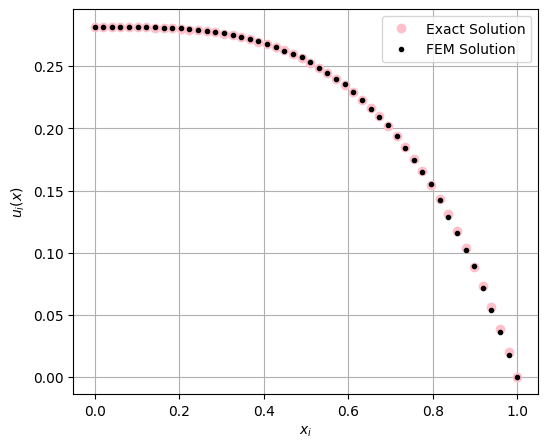

In [6]:
plt.figure(figsize=(6, 5))
plt.plot(X, exact(X),'co', c = "pink" , label='Exact Solution')
plt.plot(X, Y,'k.', label='FEM Solution')
plt.xlabel(r'$x_i$')
plt.ylabel(r'$u_i(x)$')
plt.legend(loc='best')
plt.grid()
plt.show()

### Exercise 2: Solve the EDO:  

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

In [7]:
#solucion de −d2Udx2(x)=sin(πx),  in  0≤x≤1 , with  U(0)=U(1)=0
X, Y = FEM(11, 0.0 , 0.0 , lambda x: -np.sin(np.pi*x) ,0,1)

In [8]:
#Solucion Analitica
def exact( x ):
    u = (1./np.pi**2)*np.sin(np.pi*x)
    return u

/tmp/ipykernel_41527/1272501025.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "co" (-> color='c'). The keyword argument will take precedence.
  plt.plot(X, exact(X),'co', c = "pink" , label='Exact Solution')


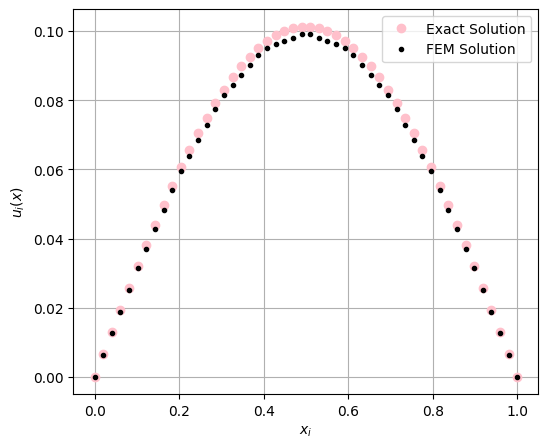

In [9]:
plt.figure(figsize=(6, 5))
plt.plot(X, exact(X),'co', c = "pink" , label='Exact Solution')
plt.plot(X, Y,'k.', label='FEM Solution')
plt.xlabel(r'$x_i$')
plt.ylabel(r'$u_i(x)$')
plt.legend(loc='best')
plt.grid()
plt.show()